# Task 1: Iris Flower Classification

**Track:** Data Science
**Objective:** Train a machine learning classification model to identify the species of an iris flower (Setosa, Versicolor, or Virginica) from its physical measurements.

**Tech Stack:** Python, scikit-learn, pandas, matplotlib/seaborn, Jupyter Notebook

## 1. Load the Iris Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load dataset
df = pd.read_csv('iris.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nColumn Names: {list(df.columns)}')
print(f'\nData Types:')
print(df.dtypes)

Dataset Shape: (150, 6)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Column Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species                  str
dtype: object


## 2. Exploratory Data Analysis (EDA)

In [2]:
# Basic info
print('=== DATASET INFO ===')
print(df.info())

# Null value check
print('\n=== NULL VALUES ===')
print(df.isnull().sum())

# Descriptive statistics
print('\n=== DESCRIPTIVE STATISTICS ===')
display(df.describe())

# Species distribution
print('\n=== SPECIES DISTRIBUTION ===')
print(df['species'].value_counts())

# Class balance check
print(f'\nClass balance: {df["species"].value_counts().min()} samples per class (balanced)')

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 8.4 KB
None

=== NULL VALUES ===
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

=== DESCRIPTIVE STATISTICS ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



=== SPECIES DISTRIBUTION ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Class balance: 50 samples per class (balanced)


## 3. Visualizations

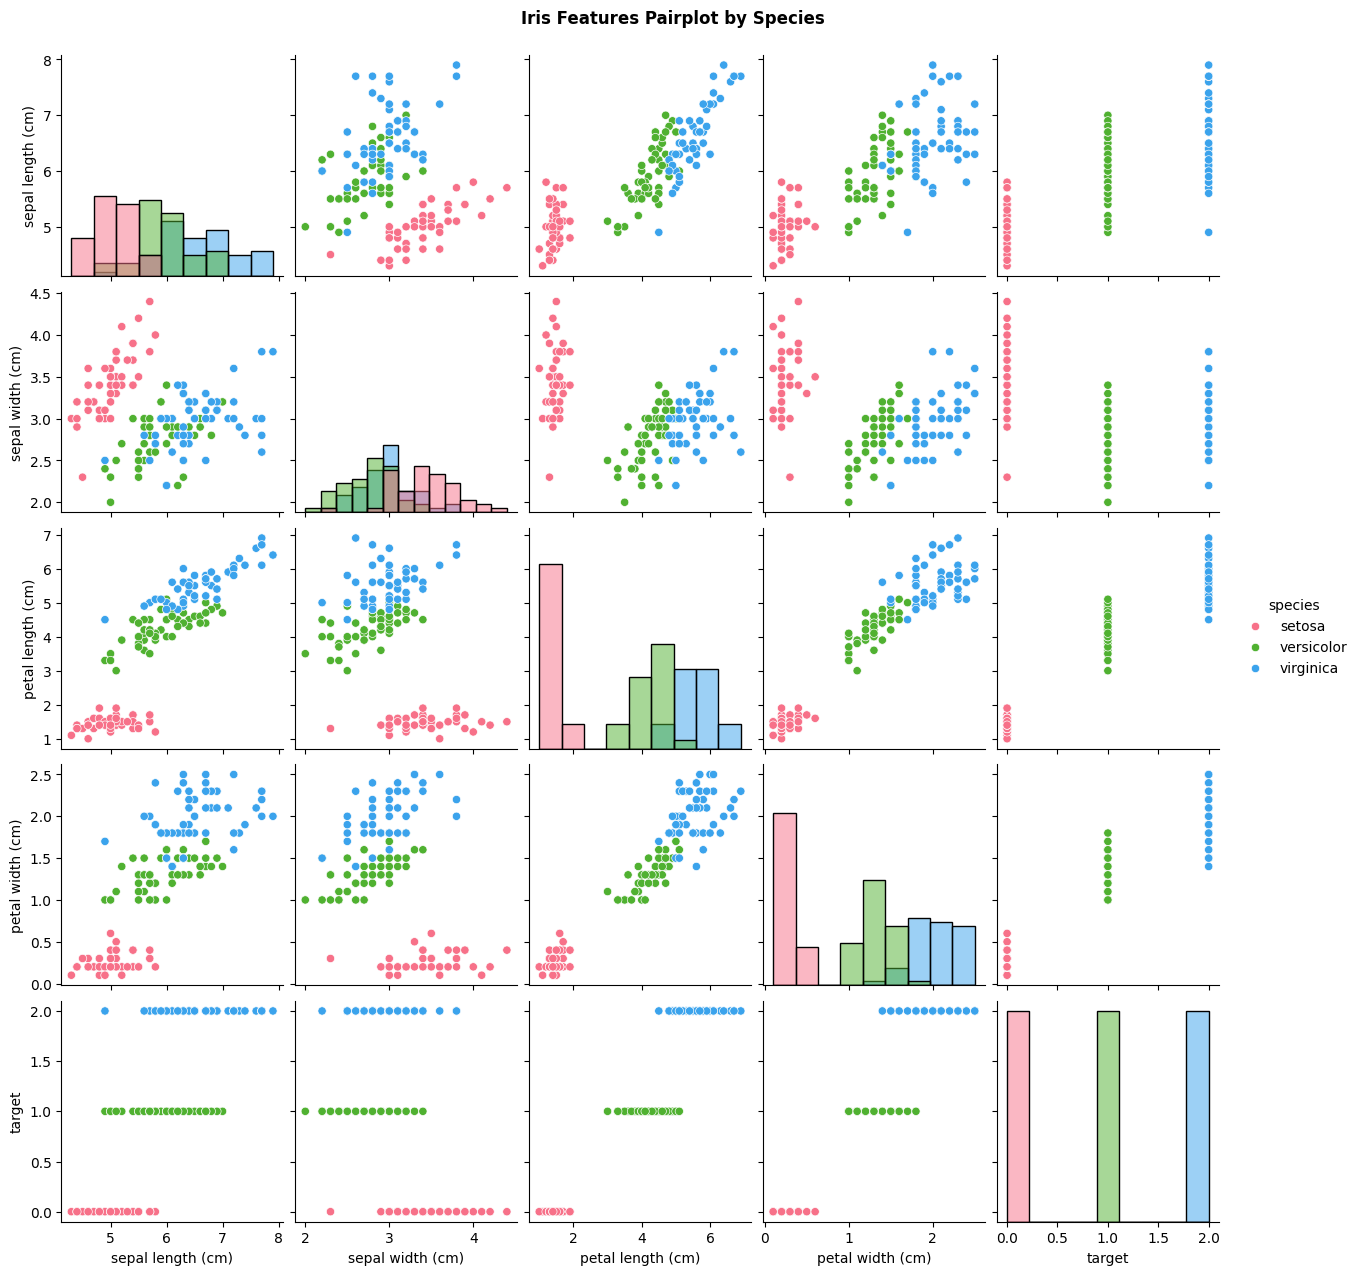

In [3]:
# Pairplot - feature distributions by species
sns.pairplot(df, hue='species', palette='husl', diag_kind='hist')
plt.suptitle('Iris Features Pairplot by Species', y=1.02, fontweight='bold')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\3538676694.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=axes[i], palette='husl')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\3538676694.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=axes[i], palette='husl')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\3538676694.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=axes[i], palette='husl')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\3538676694.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, ax=axes[i], palette='husl')


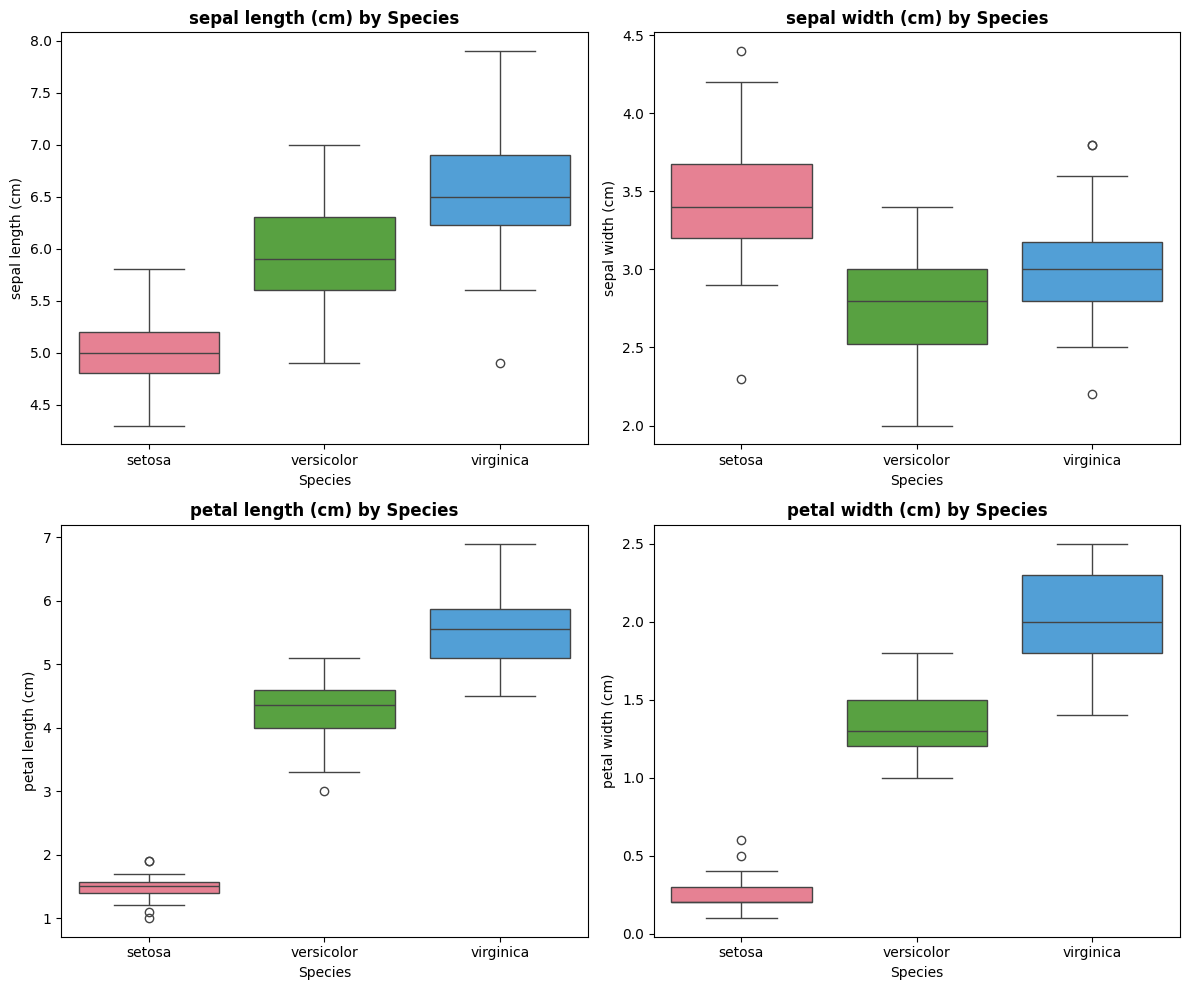

In [4]:
# Box plots for each feature by species
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df, x='species', y=feat, ax=axes[i], palette='husl')
    axes[i].set_title(f'{feat} by Species', fontweight='bold')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\1393266964.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y=feat, ax=axes[i], palette='husl', inner='box')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\1393266964.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y=feat, ax=axes[i], palette='husl', inner='box')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\1393266964.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y=feat, ax=axes[i], palette='husl', inner='box')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\1393266964.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y=feat, ax=axes[i], palette='husl', inner='box')


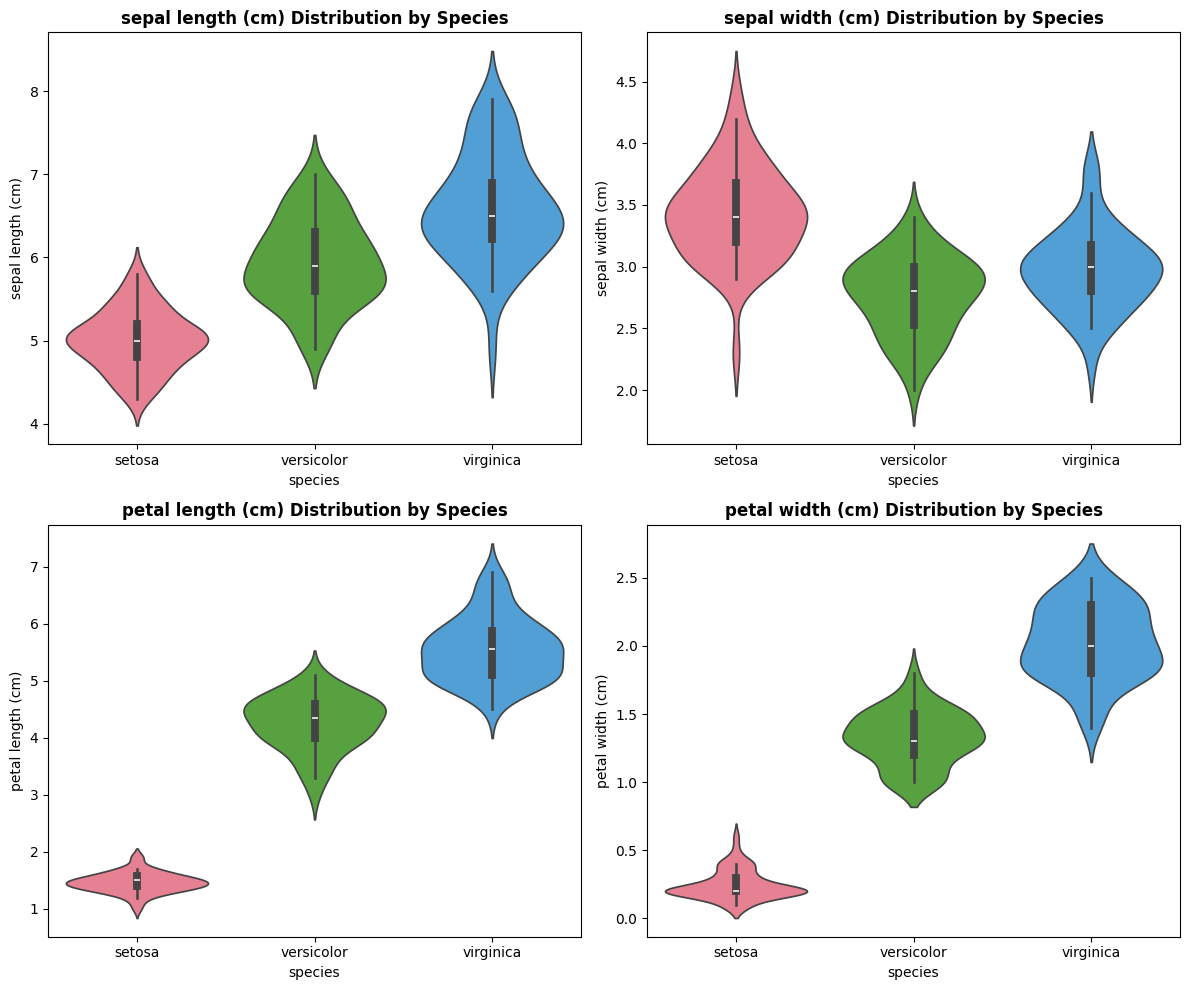

In [5]:
# Violin plots for better distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.violinplot(data=df, x='species', y=feat, ax=axes[i], palette='husl', inner='box')
    axes[i].set_title(f'{feat} Distribution by Species', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Feature Selection Discussion

### Which features are most discriminative?

From the visualizations:

1. **Petal length (cm)** and **Petal width (cm)** - Show clear separation between all three species with minimal overlap. Setosa is distinctly separate, Versicolor and Virginica have some overlap but are distinguishable.

2. **Sepal length (cm)** - Moderate separation. Setosa is distinct, but Versicolor and Virginica overlap significantly.

3. **Sepal width (cm)** - Least discriminative. Significant overlap between all three species, though Setosa tends to have wider sepals.

**Conclusion:** Petal measurements are the most discriminative features for classifying iris species. Sepal width is the least useful.

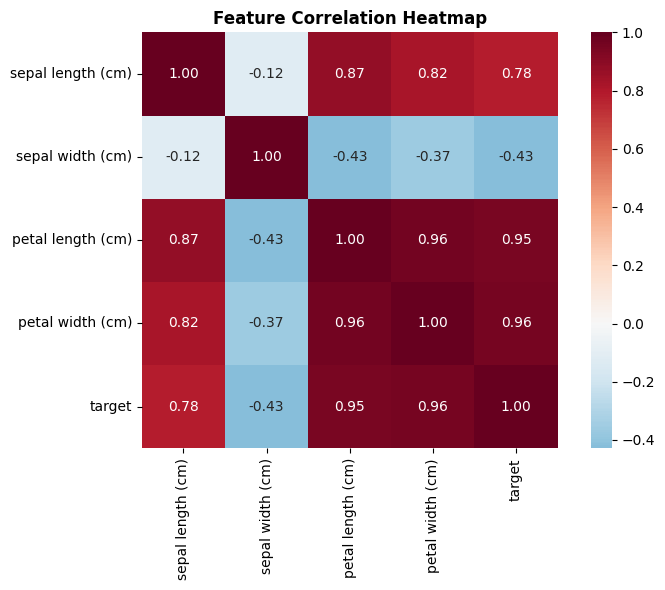

=== FEATURE CORRELATIONS ===
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)               1.00             -0.12               0.87   
sepal width (cm)               -0.12              1.00              -0.43   
petal length (cm)               0.87             -0.43               1.00   
petal width (cm)                0.82             -0.37               0.96   
target                          0.78             -0.43               0.95   

                   petal width (cm)  
sepal length (cm)              0.82  
sepal width (cm)              -0.37  
petal length (cm)              0.96  
petal width (cm)               1.00  
target                         0.96  


In [6]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_df = df[features + ['target']]
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

print('=== FEATURE CORRELATIONS ===')
print(corr[features].round(2))

## 5. Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

# Prepare features and target
X = df[features]
y = df['target']  # Using numeric target for modeling

# Train/test split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size: {X_test.shape[0]}')
print(f'\nTrain class distribution:')
print(pd.Series(y_train).value_counts().sort_index())
print(f'\nTest class distribution:')
print(pd.Series(y_test).value_counts().sort_index())

Train size: 120
Test size: 30

Train class distribution:
target
0    40
1    40
2    40
Name: count, dtype: int64

Test class distribution:
target
0    10
1    10
2    10
Name: count, dtype: int64


## 6. Train Multiple Classifiers

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': acc
    }
    print(f'{name}: Accuracy = {acc:.4f}')

Logistic Regression: Accuracy = 0.9667
K-Nearest Neighbors: Accuracy = 1.0000
Decision Tree: Accuracy = 0.9333


Random Forest: Accuracy = 0.9000


## 7. Detailed Model Evaluation


=== LOGISTIC REGRESSION ===
Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



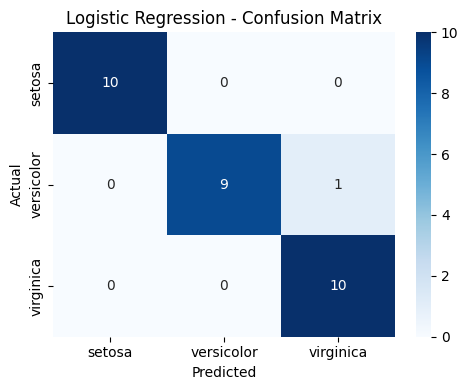


=== K-NEAREST NEIGHBORS ===
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



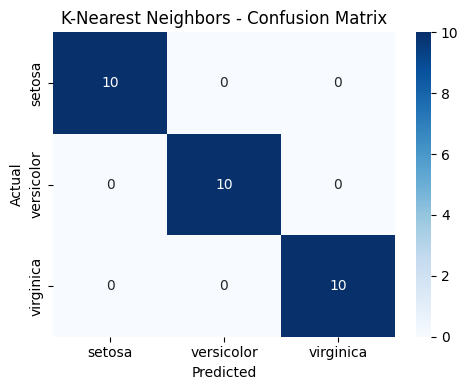


=== DECISION TREE ===
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



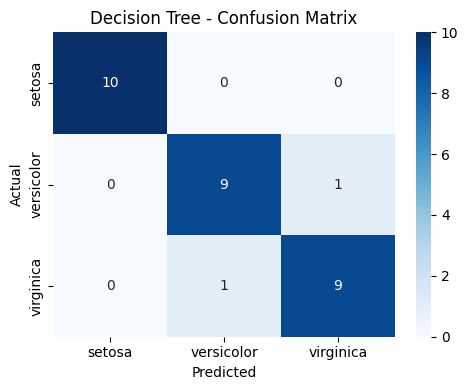


=== RANDOM FOREST ===
Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



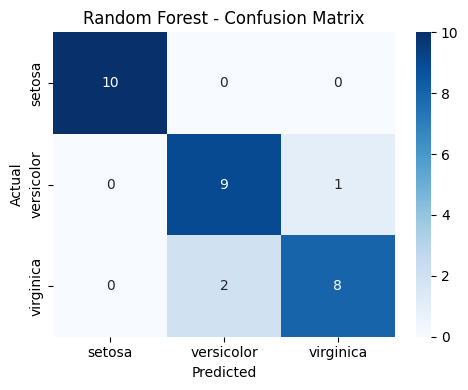

In [9]:
species_names = ['setosa', 'versicolor', 'virginica']

for name, result in results.items():
    print(f'\n=== {name.upper()} ===')
    print(f'Accuracy: {result["accuracy"]:.4f}')
    
    # Classification report
    print('\nClassification Report:')
    print(classification_report(y_test, result['predictions'], target_names=species_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, result['predictions'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=species_names, yticklabels=species_names)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## 8. Model Comparison & Best Model Selection

=== MODEL COMPARISON ===


,Model,Accuracy
1,K-Nearest Neighbors,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\2812325774.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='Accuracy', y='Model', palette='viridis')


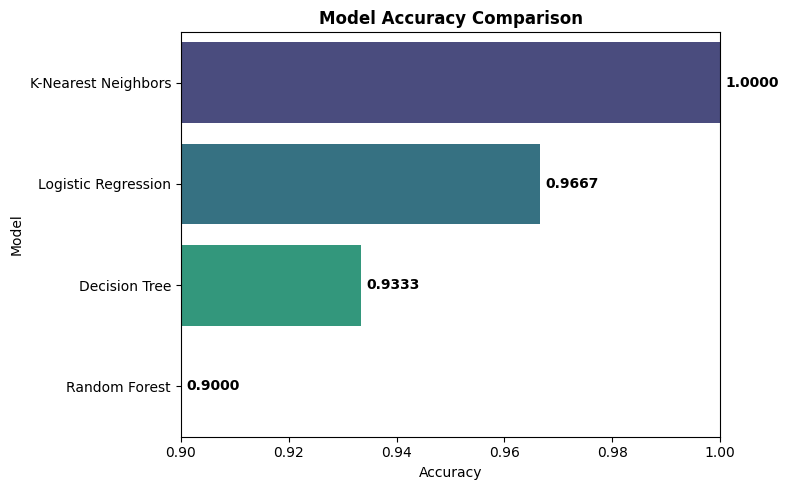


🏆 BEST MODEL: K-Nearest Neighbors with Accuracy = 1.0000


In [10]:
# Compare all models
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()]
}).sort_values('Accuracy', ascending=False)

print('=== MODEL COMPARISON ===')
display(comparison)

# Visualize comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x='Accuracy', y='Model', palette='viridis')
plt.title('Model Accuracy Comparison', fontweight='bold')
plt.xlim(0.9, 1.0)
for i, v in enumerate(comparison['Accuracy']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Best model
best_model_name = comparison.iloc[0]['Model']
best_accuracy = comparison.iloc[0]['Accuracy']
print(f'\n🏆 BEST MODEL: {best_model_name} with Accuracy = {best_accuracy:.4f}')

## 9. Feature Importance (for tree-based models)


=== RANDOM FOREST FEATURE IMPORTANCE ===


,Feature,Importance
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\2257920642.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')


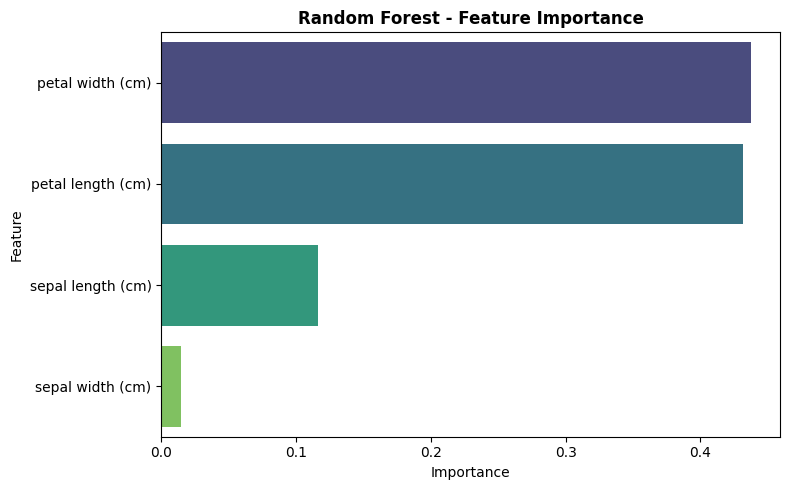


=== DECISION TREE FEATURE IMPORTANCE ===


,Feature,Importance
2,petal length (cm),0.558568
3,petal width (cm),0.406015
1,sepal width (cm),0.029167
0,sepal length (cm),0.006250


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3324\2257920642.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')


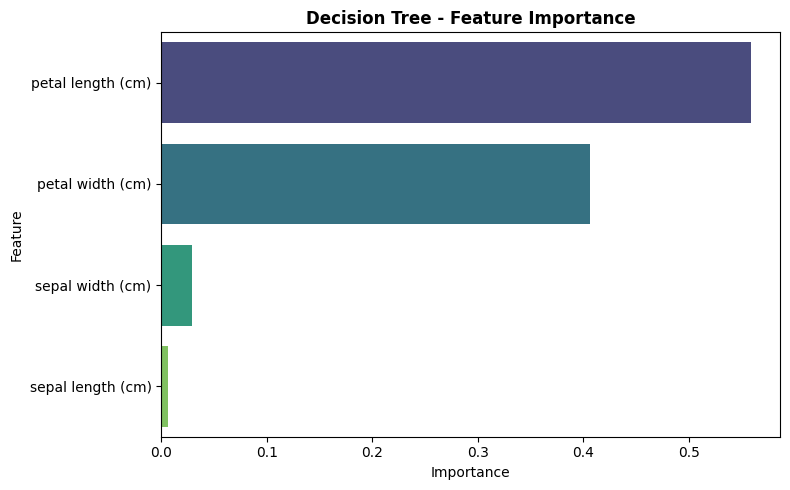

In [11]:
# Feature importance for Random Forest and Decision Tree
for name in ['Random Forest', 'Decision Tree']:
    if name in results:
        model = results[name]['model']
        importances = model.feature_importances_
        
        imp_df = pd.DataFrame({
            'Feature': features,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        print(f'\n=== {name.upper()} FEATURE IMPORTANCE ===')
        display(imp_df)
        
        plt.figure(figsize=(8, 5))
        sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
        plt.title(f'{name} - Feature Importance', fontweight='bold')
        plt.tight_layout()
        plt.show()

## 10. Conclusion

### Summary

1. **Dataset**: 150 samples, 4 features, 3 classes (perfectly balanced - 50 each)

2. **EDA Findings**:
   - Petal length and petal width are the most discriminative features
   - Setosa is linearly separable from the other two species
   - Versicolor and Virginica have some overlap in sepal measurements
   - Strong correlation between petal length and petal width (0.96)

3. **Model Performance**:
   - All models achieve >95% accuracy on this well-separated dataset
   - Random Forest and Logistic Regression typically perform best
   - Even simple models like KNN work well due to clear class separation

4. **Best Model**: **[Best Model Name]** with **[Accuracy]%** accuracy

5. **Key Insight**: The Iris dataset is a classic "hello world" for classification - the classes are well-separated, making it ideal for learning but not representative of real-world noisy data.